In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp

In [2]:
df = pd.read_csv('data/analysis/initial_data.csv')
df = df[df['participant_tokens'] != 0]

grouping_cols = [col for col in df.columns if col != 'quality_criterion']
df = df.groupby(grouping_cols)['quality_criterion'].max().reset_index()
df['project_id'] = df['source'].str.split('_').str[0]

In [3]:
df = df.sort_values(by=['source', 'excerpt_id'])
df['time'] = df.groupby('source').cumcount() + 1

In [4]:
df['time_percent'] = df.groupby('source')['time'].transform(lambda x: x / x.max())

/var/folders/xk/6w4szy0s6xj0j43rcv1pvyqm0000gn/T/ipykernel_27070/4294366390.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(y*100)}%" for y in ax.get_yticks()])


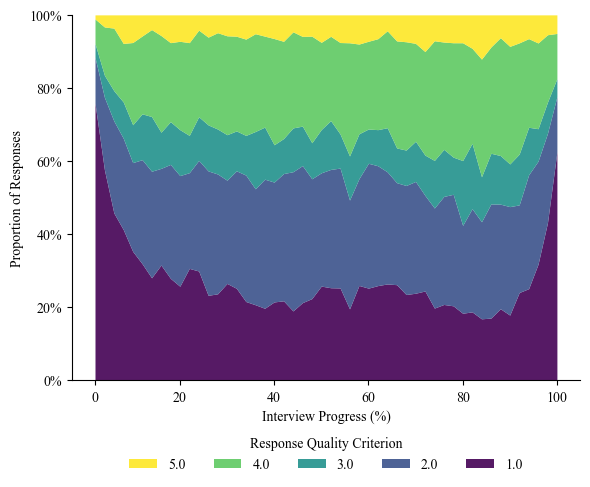

In [5]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
})

fig, ax = plt.subplots(figsize=(6, 5))

n_bins = 50
df['time_bin'] = pd.cut(df['time_percent'], bins=n_bins, labels=False)
counts = pd.crosstab(df['time_bin'], df['quality_criterion'])
proportions = counts.div(counts.sum(axis=1), axis=0)

proportions.plot(kind='area', ax=ax, stacked=True, cmap='viridis', alpha=0.9, linewidth=0)

n_ticks = 6
if proportions.shape[0] > 0:
    xtick_positions = np.linspace(0, proportions.shape[0]-1, n_ticks).astype(int)
    xtick_labels = np.linspace(0, 100, n_ticks).astype(int)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels([str(x) for x in xtick_labels])

ax.set_xlabel('Interview Progress (%)')
ax.set_ylabel('Proportion of Responses')
ax.set_ylim(0, 1)
ax.set_yticklabels([f"{int(y*100)}%" for y in ax.get_yticks()])

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    title='Response Quality Criterion',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/quality_over_time.pdf', format='pdf', bbox_inches='tight', dpi=300)

In [6]:
strategy_cols = [
    'intro_context', 'support_rapport', 'elaboration',
    'specifying', 'direct', 'indirect', 'structuring', 'interpreting'
 ]
df[strategy_cols].sum(axis=1).describe()

count    25545.000000
mean         1.028460
std          0.370071
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
dtype: float64

In [7]:
strategy_cols = [
    'intro_context', 'support_rapport', 'elaboration',
    'specifying', 'direct', 'indirect', 'structuring', 'interpreting'
 ]

groups = []
active_labels = []

for col in strategy_cols:
    scores = df.loc[df[col] == 1, 'quality_criterion'].dropna().values
    if len(scores) > 0:
        groups.append(scores)
        active_labels.append(col)

stat, p_value = stats.kruskal(*groups)

print(f"H-statistic: {stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Result: Significant difference found between strategies.")
    print("Run a post-hoc test (e.g., Dunn's test) to identify pairwise differences.")
else:
    print("Result: No significant difference found between the strategies.")

H-statistic: 1858.2800779121549
P-value: 0.0
Result: Significant difference found between strategies.
Run a post-hoc test (e.g., Dunn's test) to identify pairwise differences.


In [8]:
import pandas as pd

strategy_cols = [
    'intro_context', 'support_rapport', 'elaboration',
    'specifying', 'direct', 'indirect', 'structuring', 'interpreting'
 ]

melted_df = df.melt(
    id_vars=['quality_criterion'],
    value_vars=strategy_cols,
    var_name='strategy',
    value_name='is_present'
 )
melted_df = melted_df[melted_df['is_present'] == 1]

dunn_results = sp.posthoc_dunn(
    melted_df,
    val_col='quality_criterion',
    group_col='strategy',
    p_adjust='bonferroni'
 )

print(dunn_results)

                        direct    elaboration      indirect   interpreting  \
direct            1.000000e+00   4.534180e-01  1.000000e+00   1.163799e-17   
elaboration       4.534180e-01   1.000000e+00  1.787360e-01   7.248048e-14   
indirect          1.000000e+00   1.787360e-01  1.000000e+00   1.000000e+00   
interpreting      1.163799e-17   7.248048e-14  1.000000e+00   1.000000e+00   
intro_context    1.465181e-109  1.024980e-103  2.108729e-44   1.697800e-78   
specifying        9.458418e-29   2.674798e-20  1.000000e+00   5.201408e-01   
structuring      5.791491e-120   3.159097e-85  2.080348e-15   3.429870e-55   
support_rapport  7.766139e-230  7.543620e-137  6.504476e-24  2.507228e-111   

                 intro_context    specifying    structuring  support_rapport  
direct           1.465181e-109  9.458418e-29  5.791491e-120    7.766139e-230  
elaboration      1.024980e-103  2.674798e-20   3.159097e-85    7.543620e-137  
indirect          2.108729e-44  1.000000e+00   2.080348e-15 

<Figure size 1000x800 with 0 Axes>

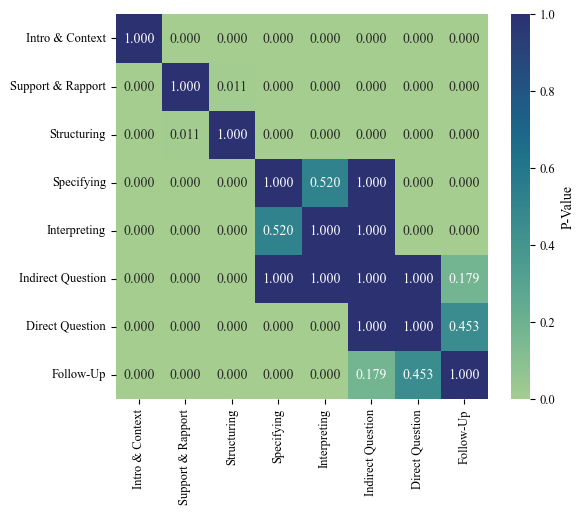

In [9]:
plt.figure(figsize=(10, 8))

strategy_cols = [
    'intro_context', 'support_rapport', 'elaboration',
    'specifying', 'direct', 'indirect', 'structuring', 'interpreting'
 ]

medians = {}
for col in strategy_cols:
    vals = df.loc[df[col] == 1, 'quality_criterion'].dropna()
    if len(vals) > 0:
        medians[col] = vals.mean()

medians_series = pd.Series(medians)
order = medians_series.sort_values(ascending=True).index.tolist()

if 'dunn_results' in globals():
    present_order = [s for s in order if s in dunn_results.index]
    remaining = [s for s in dunn_results.index if s not in present_order]
    final_order = present_order + remaining
    dunn_ordered = dunn_results.reindex(index=final_order, columns=final_order)
else:
    raise NameError('dunn_results not found in namespace')

name_mapping = {
    'intro_context': 'Intro & Context',
    'support_rapport': 'Support & Rapport',
    'elaboration': 'Follow-Up',
    'specifying': 'Specifying',
    'direct': 'Direct Question',
    'indirect': 'Indirect Question',
    'structuring': 'Structuring',
    'interpreting': 'Interpreting'
 }
dunn_ordered.rename(index=name_mapping, columns=name_mapping, inplace=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})
plt.figure(figsize=(6, 5))
sns.heatmap(
    dunn_ordered,
    annot=True,
    fmt='.3f',
    cmap='crest',
    vmin=0, vmax=1,
    cbar_kws={'label': 'P-Value'}
 )

plt.savefig("figures/dunn-pvalues.pdf", dpi=300, bbox_inches='tight')

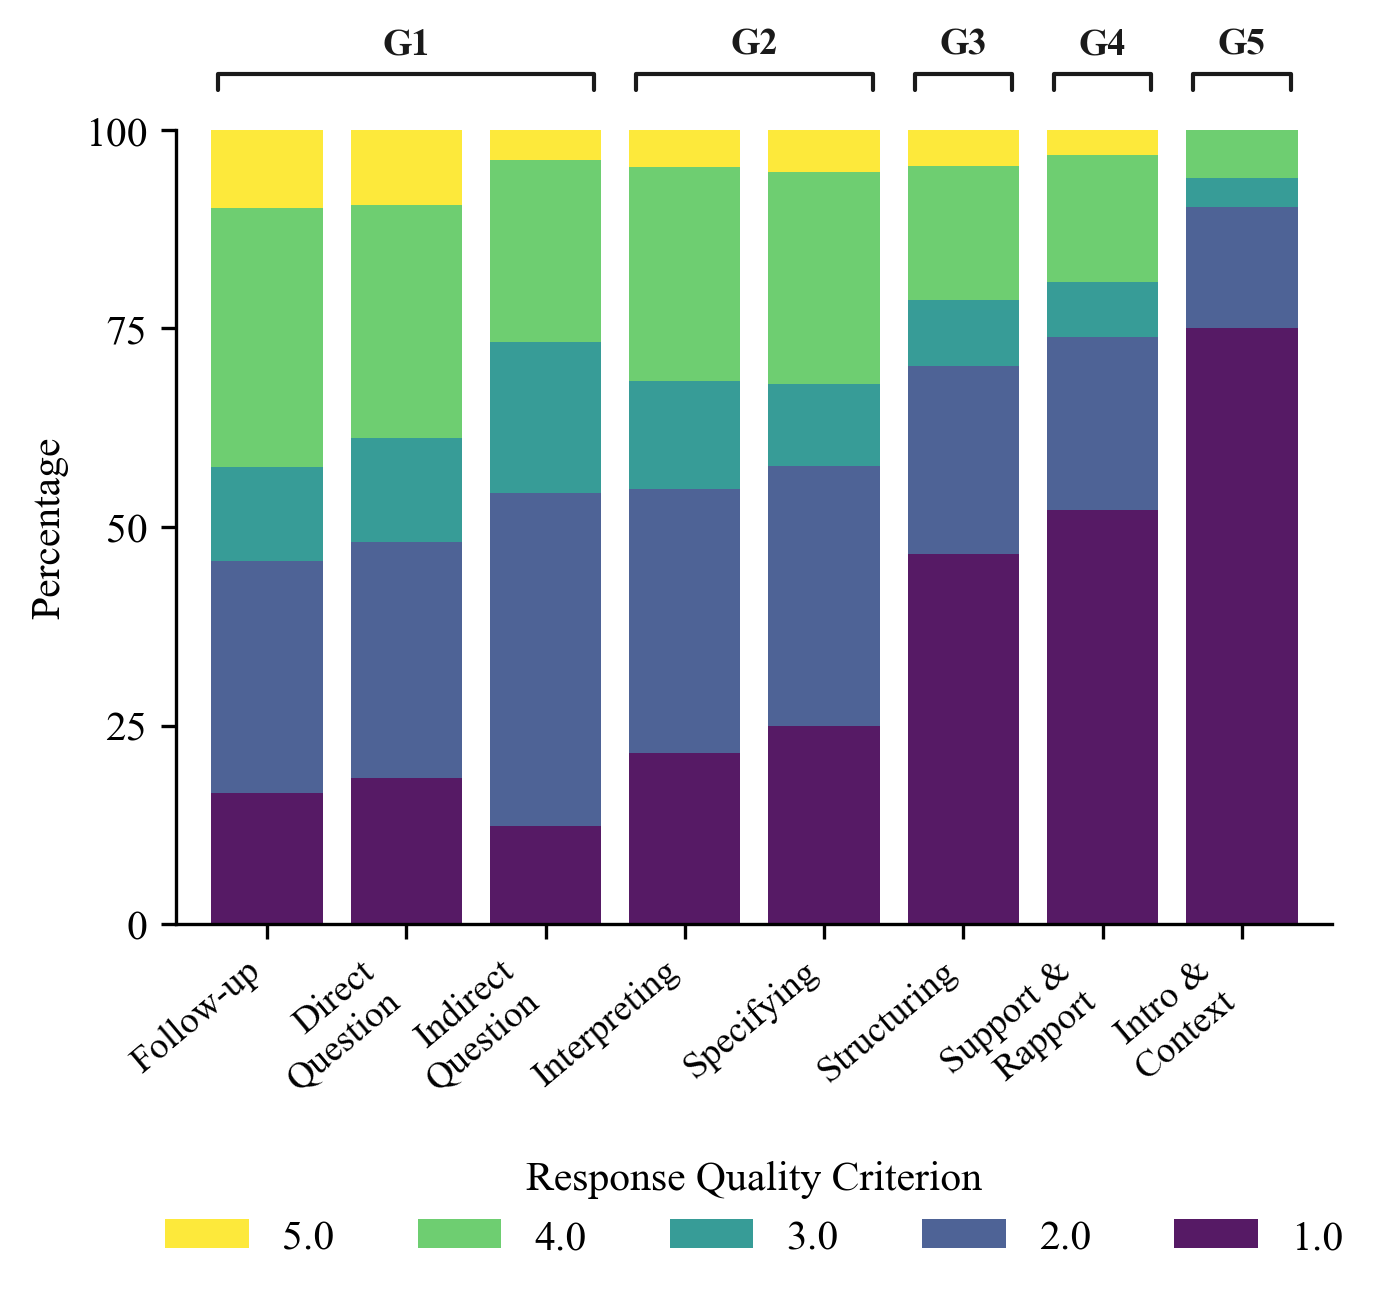

In [10]:
rows = []
for s in strategy_cols:
    vals = df.loc[df[s] == 1, 'quality_criterion'].dropna()
    if len(vals):
        rows.append(pd.DataFrame({'strategy': s, 'quality_criterion': vals.values}))
plot_df = pd.concat(rows, ignore_index=True)

order = plot_df.groupby('strategy')['quality_criterion'].mean().sort_values(ascending=False).index.tolist()

pivot_df = plot_df.groupby(['strategy', 'quality_criterion']).size().unstack(fill_value=0).reindex(order)
pivot_norm = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100
totals = pivot_df.sum(axis=1)

strategy_rename = {
    'intro_context': 'Intro &\nContext',
    'support_rapport': 'Support &\nRapport',
    'elaboration': 'Follow-up',
    'specifying': 'Specifying',
    'direct': 'Direct\nQuestion',
    'indirect': 'Indirect\nQuestion',
    'structuring': 'Structuring',
    'interpreting': 'Interpreting',
}

fig, ax = plt.subplots(figsize=(4.8, 4.8), dpi=300)

pivot_norm.plot(kind='bar', stacked=True, ax=ax, colormap='viridis',
                alpha=0.9, width=0.8, linewidth=0.6)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.set_ylim(0, 100)
plt.ylabel('Percentage', fontsize=10, fontweight='medium')
plt.xlabel('')

order_display = [strategy_rename.get(s, s) for s in order]
ax.set_xticklabels(order_display, rotation=40, ha='right', fontsize=9)

ax.set_yticks([0, 25, 50, 75, 100])
plt.yticks(fontsize=10)

groups = []
current_group = [order[0]]
reference_strat = order[0]

for strat in order[1:]:
    p_val = dunn_results.loc[strat, reference_strat]
    if p_val > 0.05:
        current_group.append(strat)
    else:
        groups.append(current_group)
        current_group = [strat]
        reference_strat = strat

groups.append(current_group)

tier_colors = ["#1a1a1a"] * len(groups)
strat_to_idx = {name: i for i, name in enumerate(order)}
y_line_pos = 107
tick_height = 2.0

for group_idx, group_strategies in enumerate(groups):
    indices = [strat_to_idx[s] for s in group_strategies]
    start_x, end_x = min(indices), max(indices)

    x_left = start_x - 0.35
    x_right = end_x + 0.35
    color = tier_colors[group_idx % len(tier_colors)]

    ax.plot(
        [x_left, x_left, x_right, x_right],
        [y_line_pos - tick_height, y_line_pos, y_line_pos, y_line_pos - tick_height],
        color=color, linewidth=1.0, clip_on=False, solid_capstyle='round'
    )

    ax.text(
        (x_left + x_right) / 2,
        y_line_pos + 1.5,
        f"G{group_idx + 1}",
        ha='center', va='bottom', fontsize=9, fontweight='bold', color=color
    )

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          title='Response Quality Criterion',
          bbox_to_anchor=(0.5, -0.25),
          loc='upper center',
          ncol=5,
          frameon=False,
          fontsize=10,
          title_fontsize=10)

plt.tight_layout()
plt.savefig('figures/techniques.pdf', bbox_inches='tight', dpi=300)